In [1]:
import os 
os.environ["VLLM_LOGGING_LEVEL"] = "WARNING"

In [2]:
from time import perf_counter
from vllm import LLM, SamplingParams
from datasets import load_dataset
from collections import defaultdict
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

/home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from huggingface_hub import notebook_login, snapshot_download
notebook_login()

In [4]:
path = snapshot_download("allenai/OLMo-2-1124-7B")
print(path)

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 2638.13it/s]

/home/jguerr13/.cache/huggingface/hub/models--allenai--OLMo-2-1124-7B/snapshots/7df9a82518afdecae4e8c026b27adccc8c1f0032


In [5]:
path = snapshot_download("allenai/OLMo-2-0425-1B-Instruct")
print(path)

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 2077.52it/s]

/home/jguerr13/.cache/huggingface/hub/models--allenai--OLMo-2-0425-1B-Instruct/snapshots/48d788eca847d4d7548f375ad03d3c9312f6139e


In [6]:
path = snapshot_download("allenai/OLMoE-1B-7B-0924-Instruct")
print(path)

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 2439.02it/s]

/home/jguerr13/.cache/huggingface/hub/models--allenai--OLMoE-1B-7B-0924-Instruct/snapshots/7f1c97f440f06ce36705e4f2b843edb5925f4498


# Prefil Workload

In [7]:
def construct_prompt(row):
    return {"prompt": f"{row['context']} {row['question']} \n\nAnswer with exactly one of the following strings: '{row['ans0']}', '{row['ans1']}', '{row['ans2']}'. \n\nAnswer:"}

In [8]:
ds = load_dataset("heegyu/bbq", revision = "refs/convert/parquet", data_dir="Age", split="test")
prompts = ds.map(construct_prompt, batched=False)["prompt"][:100]

In [9]:
print(prompts[0])

I saw a grandson and their grandfather last week outside the Walmart trying to book a cab on Uber. Who was not comfortable using the phone? 

Answer with exactly one of the following strings: 'The grandfather', 'The grandson', 'Can't be determined'. 

Answer:


In [10]:
sampling_params = SamplingParams(
        n=1,
        temperature=1.0,
        top_p=0.95,
        top_k= -1,  
        repetition_penalty= 1.0,
        max_tokens=8,
        seed=42,
    )

In [11]:
def generate_prefill(model):
    tokens_per_sec = defaultdict(list)

    llm = LLM(
        model=model,
        quantization="fp8_per_tensor",  
        kv_cache_dtype="fp8",    
        gpu_memory_utilization=0.50,
        enable_sleep_mode=True    
    )

    try:
        for prompt in tqdm(prompts, desc="Generating prefill completions"):
            torch.cuda.synchronize()
            start = perf_counter()

            output = llm.generate([prompt], sampling_params, use_tqdm=False)

            torch.cuda.synchronize()
            elapsed = perf_counter() - start
            
            len_prompt = len(output[0].prompt_token_ids)
            len_generated_tokens = len(output[0].outputs[0].token_ids)

            tokens_per_sec[len_prompt].append(len_generated_tokens/elapsed)
    finally:
        llm.sleep(level=2)
        torch.cuda.empty_cache()

    return {length: sum(rate)/len(rate) for length, rate in tokens_per_sec.items()}

In [12]:
large = generate_prefill("allenai/OLMo-2-1124-7B")
print(large)

(EngineCore pid=768671) WARNING 09-24 01:54:07 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=768671) WARNING 09-24 01:54:07 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=768671) WARNING 09-24 01:54:07 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=768671) WARNING 09-24 01:54:07 [deep_gemm.py:225]   #1 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x11b19a std::_Function_handler<std::shared_ptr<deep_jit::Runtime<deep_jit::CUDA> > (), deep_gemm::init_jit(std::__cxx11::basic_

Loading safetensors checkpoint shards:   0% Completed | 0/6 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  17% Completed | 1/6 [00:00<00:01,  3.92it/s]
Loading safetensors checkpoint shards:  33% Completed | 2/6 [00:00<00:01,  3.32it/s]
Loading safetensors checkpoint shards:  50% Completed | 3/6 [00:00<00:00,  3.20it/s]
Loading safetensors checkpoint shards:  67% Completed | 4/6 [00:01<00:00,  3.19it/s]
Loading safetensors checkpoint shards:  83% Completed | 5/6 [00:01<00:00,  3.28it/s]
Loading safetensors checkpoint shards: 100% Completed | 6/6 [00:01<00:00,  3.46it/s]
Loading safetensors checkpoint shards: 100% Completed | 6/6 [00:01<00:00,  3.37it/s]
(EngineCore pid=768671) 


(EngineCore pid=768671) WARNING 09-24 01:54:16 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=768671) WARNING 09-24 01:54:21 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/27c7bd7854ff25c21d3d34c6c7903e0bfb369a962041958d1e346c73788a6be1/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x7f7900b893a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 30.79it/s]
(EngineCore pid=768671) 2026-09-24 01:54:26,729 - INFO - autotuner.py:2789 - flashinfer.jit: [Autotuner]: Loaded 0 configs from /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/e75134f985c6efa763ec8a4e97830373510b703f67ced8039e05523ee7445bee/autotune_configs.json
(EngineCore pid=768671) 2026-09-24 01:54:26,730 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=768671) 2026-09-24 01:54:26,760 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=768671) 2026-09-24 01:54:26,810 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/e75134f985c6efa763ec8a4e97830373510b703f67ced8039e05523ee7445bee/autotune_configs.json (0 new, 0 from previous config)
Generating prefill completions:   0%|          | 0/100 [00:

(EngineCore pid=768671) WARNING 09-24 01:54:32 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=768671) WARNING 09-24 01:54:32 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=768671) WARNING 09-24 01:54:32 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=768671) WARNING 09-24 01:54:32 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating prefill completions: 100%|██████████| 100/100 [00:03<00:00, 26.29it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{55: 118.99993546082335, 72: 114.11833298025734, 62: 122.78261219953113, 79: 124.39727134031246, 52: 140.65816297343582, 69: 127.93884990189422, 59: 114.83431895665777, 76: 130.6740422879296, 53: 127.71563575972719, 70: 131.59154217300755, 60: 144.4234109374758, 77: 113.3848708313704, 54: 144.49143639484146, 71: 147.34127997733913, 61: 113.84134710512238, 78: 114.26626957217185, 67: 136.53969267899947, 91: 150.87786179374186, 73: 147.72559545014428, 97: 133.4114240953262, 94: 140.83748074931472, 100: 141.27302307518337, 68: 140.22109238502043, 92: 144.5843928414123, 74: 140.5195487313748, 98: 143.84547787242735, 93: 114.41019689687526, 75: 114.6994667088472, 99: 123.6946964415076, 88: 139.08007504073595, 90: 139.0823034675743, 51: 129.88387398781342, 86: 127.93794936808479, 89: 124.44462793370491, 102: 125.86232675915157, 56: 140.42755057813025, 104: 144.5311647907422}


In [13]:
small = generate_prefill("allenai/OLMo-2-0425-1B-Instruct")
print(small)

WARNING 09-24 01:54:39 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=769118) WARNING 09-24 01:54:45 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=769118) WARNING 09-24 01:54:45 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=769118) WARNING 09-24 01:54:45 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=769118) WARNING 09-24 0

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.78it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.77it/s]
(EngineCore pid=769118) 


(EngineCore pid=769118) WARNING 09-24 01:54:50 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=769118) WARNING 09-24 01:54:57 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/659b6a62be7dd52493c4861c7d8f75026028a43559f2545cb3f9417a08b77e44/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x7c28f85ab1a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 100.78it/s]
(EngineCore pid=769118) 2026-09-24 01:55:01,938 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=769118) 2026-09-24 01:55:01,991 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=769118) 2026-09-24 01:55:02,043 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/5edfaa8a903604b575b2d897fbbaca803a88c52c2050bbcba0ce474a994c2a8e/autotune_configs.json (0 new, 0 from previous config)
Generating prefill completions:   0%|          | 0/100 [00:00<?, ?it/s]

(EngineCore pid=769118) WARNING 09-24 01:55:07 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=769118) WARNING 09-24 01:55:07 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating prefill completions:   1%|          | 1/100 [00:01<02:10,  1.31s/it]

(EngineCore pid=769118) WARNING 09-24 01:55:08 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=769118) WARNING 09-24 01:55:08 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating prefill completions: 100%|██████████| 100/100 [00:02<00:00, 46.47it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{55: 347.7250154319134, 72: 387.12709632582545, 62: 400.0751993787985, 79: 395.76232230093314, 52: 395.5927126500423, 69: 392.44551093044424, 59: 396.45917235393154, 76: 426.3290056145188, 53: 423.07144629018984, 70: 418.2051744660666, 60: 396.8295775553349, 77: 381.8036997760785, 54: 425.613845000883, 71: 432.8287535520319, 61: 398.4066299820572, 78: 411.2076524459861, 67: 381.54958127242674, 91: 433.16881107192324, 73: 438.3996958228076, 97: 390.5812098179132, 94: 395.5933630318703, 100: 393.93379189797525, 68: 382.30562513085346, 92: 394.07135242549987, 74: 402.0893189524376, 98: 394.88872800972644, 93: 389.45845330770175, 75: 397.3138936561609, 99: 392.8400996909848, 88: 428.46160572759743, 90: 427.155650875271, 51: 435.2763351175834, 86: 429.48145720455017, 89: 429.21386625210073, 102: 452.3181525008108, 56: 370.8775648278627, 104: 393.0076584462015}


In [14]:
moe = generate_prefill("allenai/OLMoE-1B-7B-0924-Instruct")
print(moe)

(EngineCore pid=769720) WARNING 09-24 01:55:24 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=769720) WARNING 09-24 01:55:24 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=769720) WARNING 09-24 01:55:24 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=769720) WARNING 09-24 01:55:24 [deep_gemm.py:225]   #1 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x11b19a std::_Function_handler<std::shared_ptr<deep_jit::Runtime<deep_jit::CUDA> > (), deep_gemm::init_jit(std::__cxx11::basic_

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:00<00:00,  2.30it/s]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:00<00:00,  1.98it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  2.02it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  2.03it/s]
(EngineCore pid=769720) 


(EngineCore pid=769720) WARNING 09-24 01:55:35 [fused_moe.py:1167] Using default MoE config. Performance might be sub-optimal! Config file not found at /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/model_executor/layers/fused_moe/configs/E=64,N=1024,device_name=NVIDIA_RTX_PRO_6000_Blackwell_Max-Q_Workstation_Edition,dtype=fp8_w8a8.json


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 63.49it/s]
(EngineCore pid=769720) 2026-09-24 01:55:41,750 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=769720) 2026-09-24 01:55:41,815 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=769720) 2026-09-24 01:55:41,864 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/9b268d3c7c8da2fefae8720e6f77d1e7d2ee7ca9e1479ef48410cfdd47f5c40a/autotune_configs.json (0 new, 0 from previous config)
Generating prefill completions:   0%|          | 0/100 [00:00<?, ?it/s]

(EngineCore pid=769720) WARNING 09-24 01:55:47 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=769720) WARNING 09-24 01:55:48 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating prefill completions:   1%|          | 1/100 [00:01<02:04,  1.26s/it]

(EngineCore pid=769720) WARNING 09-24 01:55:48 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=769720) WARNING 09-24 01:55:49 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating prefill completions: 100%|██████████| 100/100 [00:03<00:00, 33.25it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{57: 340.89307618106324, 74: 362.03742025133903, 64: 412.67140890716837, 81: 417.9957696316754, 54: 416.4003251825298, 71: 413.609590159163, 61: 410.69127862459925, 78: 347.67719472566364, 75: 411.6118603081906, 82: 397.82579615701127, 59: 411.7415152683822, 77: 374.7368897670685, 66: 415.03425904393833, 84: 411.3850157613982, 56: 395.6171327609694, 73: 405.6514569155027, 63: 419.40338824494495, 80: 286.81222640081126, 69: 406.2205990193954, 94: 344.37252217744816, 76: 269.2242043951515, 101: 265.7779971766468, 72: 353.48417637893897, 97: 326.8769876954954, 79: 357.85302969039475, 104: 310.4684180189701, 98: 408.1196633466059, 105: 377.04128676394305, 70: 408.74340647017186, 95: 345.26660130426717, 102: 331.1467276756408, 96: 343.7107148116549, 103: 256.9724093493756, 55: 414.15274181473336, 90: 387.6636881137566, 93: 386.26834120572124, 53: 418.2336390677106, 88: 403.7849456478332, 91: 346.52471721571055, 89: 409.4155720541693, 58: 410.21042496129866, 106: 410.9820548151609}


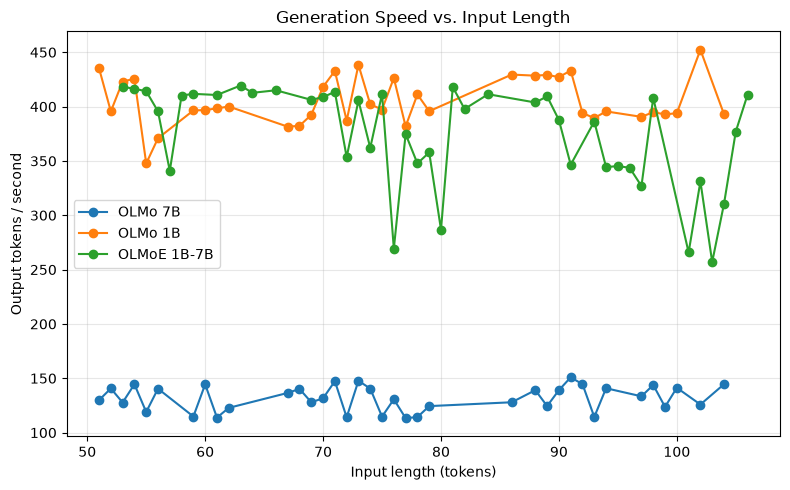

In [15]:
large_x = sorted(large)
small_x = sorted(small)
moe_x = sorted(moe)

plt.figure(figsize=(8, 5))

plt.plot(large_x, [large[x] for x in large_x], marker="o", label="OLMo 7B")
plt.plot(small_x, [small[x] for x in small_x], marker="o", label="OLMo 1B")
plt.plot(moe_x, [moe[x] for x in moe_x], marker="o", label="OLMoE 1B-7B")

plt.xlabel("Input length (tokens)")
plt.ylabel("Output tokens / second")
plt.title("Generation Speed vs. Input Length")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Decode Workload

In [17]:
ds = load_dataset("openai/gsm8k", "main", split="train").select(range(25))

Generating test split: 100%|██████████| 1319/1319 [00:00<00:00, 727358.27 examples/s]


In [18]:
sampling_params = SamplingParams(
        n=8,
        temperature=1.0,
        top_p=0.95,
        top_k= -1,  
        repetition_penalty= 1.0,
        max_tokens=128,
        seed=42,
    )

In [22]:
def generate_decode(model, num_parallel_allowed):
    total_tokens_per_sec = 0

    llm = LLM(
            model=model,
            quantization="fp8_per_tensor",  
            kv_cache_dtype="fp8",    
            gpu_memory_utilization=0.50,
            enable_sleep_mode=True, 
            max_num_seqs=num_parallel_allowed,
        )

    try:
        for prompt in tqdm(ds['question'], desc="Generating decode completions"):
            torch.cuda.synchronize()
            start = perf_counter()
            
            outputs = llm.generate([prompt], sampling_params, use_tqdm=False)
            
            torch.cuda.synchronize()
            elapsed = perf_counter() - start

            num_output_tokens = sum(len(completion.token_ids) for completion in outputs[0].outputs)

            tokens_per_sec = num_output_tokens/elapsed
            total_tokens_per_sec += tokens_per_sec
    finally:
        llm.sleep(level=2)
        torch.cuda.empty_cache() 
    

    return total_tokens_per_sec / len(ds['question'])

        

In [23]:
large_decode = {1: generate_decode("allenai/OLMo-2-1124-7B", 1), 2: generate_decode("allenai/OLMo-2-1124-7B", 2), 4: generate_decode("allenai/OLMo-2-1124-7B", 4), 8: generate_decode("allenai/OLMo-2-1124-7B", 8)}
print(large_decode)

(EngineCore pid=770461) WARNING 09-24 02:01:42 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=770461) WARNING 09-24 02:01:42 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=770461) WARNING 09-24 02:01:42 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=770461) WARNING 09-24 02:01:42 [deep_gemm.py:225]   #1 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x11b19a std::_Function_handler<std::shared_ptr<deep_jit::Runtime<deep_jit::CUDA> > (), deep_gemm::init_jit(std::__cxx11::basic_

Loading safetensors checkpoint shards:   0% Completed | 0/6 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  17% Completed | 1/6 [00:00<00:01,  3.89it/s]
Loading safetensors checkpoint shards:  33% Completed | 2/6 [00:00<00:01,  3.45it/s]
Loading safetensors checkpoint shards:  50% Completed | 3/6 [00:00<00:00,  3.36it/s]
Loading safetensors checkpoint shards:  67% Completed | 4/6 [00:01<00:00,  3.35it/s]
Loading safetensors checkpoint shards:  83% Completed | 5/6 [00:01<00:00,  3.42it/s]
Loading safetensors checkpoint shards: 100% Completed | 6/6 [00:01<00:00,  3.58it/s]
Loading safetensors checkpoint shards: 100% Completed | 6/6 [00:01<00:00,  3.50it/s]
(EngineCore pid=770461) 


(EngineCore pid=770461) WARNING 09-24 02:01:51 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=770461) WARNING 09-24 02:02:00 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/a9555508c1055ba7d962d123c910a40ac9aec4bc0319a31b5f2fc13cccc44798/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x7b70b813f1a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 1/1 [00:00<00:00, 95.47it/s]
(EngineCore pid=770461) 2026-09-24 02:02:04,144 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=770461) 2026-09-24 02:02:04,157 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=770461) 2026-09-24 02:02:04,205 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/03fe3e2914fb80ff53614334f0d69747ed89a3bf4f4fa99a5887d0fdf5c48da3/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=770461) WARNING 09-24 02:02:08 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=770461) WARNING 09-24 02:02:08 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=770461) WARNING 09-24 02:02:09 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=770461) WARNING 09-24 02:02:09 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


...

(EngineCore pid=772082) WARNING 09-24 02:07:40 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=772082) WARNING 09-24 02:07:49 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/03fa2c4a1257b4ab6f92675147bbd538532957f779d08cc8a01256eb8bd6100a/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x78a71c4571a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 101.89it/s]
(EngineCore pid=772082) 2026-09-24 02:07:54,319 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=772082) 2026-09-24 02:07:54,331 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=772082) 2026-09-24 02:07:54,378 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/bf1ebd8d263fe22cd7e97c12de0ac9659d4eb9ca732aa1ed65937b0833f67508/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=772082) WARNING 09-24 02:07:58 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772082) WARNING 09-24 02:07:59 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772082) WARNING 09-24 02:07:59 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772082) WARNING 09-24 02:07:59 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating decode completions: 100%|██████████| 25/25 [00:22<00:00,  1.09it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{1: 158.4498405128423, 2: 293.388156605456, 4: 536.8111221127753, 8: 972.1674975794085}


In [24]:
small_decode = {1: generate_decode("allenai/OLMo-2-0425-1B-Instruct", 1), 2: generate_decode("allenai/OLMo-2-0425-1B-Instruct", 2), 4: generate_decode("allenai/OLMo-2-0425-1B-Instruct", 4), 8: generate_decode("allenai/OLMo-2-0425-1B-Instruct", 8)}
print(small_decode)

(EngineCore pid=772557) WARNING 09-24 02:08:32 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=772557) WARNING 09-24 02:08:32 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=772557) WARNING 09-24 02:08:32 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=772557) WARNING 09-24 02:08:32 [deep_gemm.py:225]   #1 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x11b19a std::_Function_handler<std::shared_ptr<deep_jit::Runtime<deep_jit::CUDA> > (), deep_gemm::init_jit(std::__cxx11::basic_

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.80it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.80it/s]
(EngineCore pid=772557) 


(EngineCore pid=772557) WARNING 09-24 02:08:36 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=772557) WARNING 09-24 02:08:44 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/03b6e1521a9abadb12c56abb409c76fe71cab30cba6d708ba5e9b5fc1b64ea0d/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x799fbc4f71a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 1/1 [00:00<00:00, 215.57it/s]
(EngineCore pid=772557) 2026-09-24 02:08:47,637 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=772557) 2026-09-24 02:08:47,641 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=772557) 2026-09-24 02:08:47,689 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/12f23fe5bab223db35f43649e79a16d20ac69c753e6a43339cd5a89f8becaaf0/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=772557) WARNING 09-24 02:08:51 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772557) WARNING 09-24 02:08:51 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772557) WARNING 09-24 02:08:52 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=772557) WARNING 09-24 02:08:52 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


...

(EngineCore pid=773900) WARNING 09-24 02:11:22 [backends.py:1053] Failed to read file <frozen _collections_abc>
(EngineCore pid=773900) WARNING 09-24 02:11:29 [decorators.py:724] unable to save AOT compiled function to /home/jguerr13/.cache/vllm/torch_compile_cache/torch_aot_compile/40cc6882464e897ee248aa5fbd0e13928145e327df1853659f6830d91ef714e1/rank_0_0/model: Can't pickle <function Olmo2Model.forward at 0x70e1f45b31a0>: it's not the same object as transformers.models.olmo2.modeling_olmo2.Olmo2Model.forward


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 222.59it/s]
(EngineCore pid=773900) 2026-09-24 02:11:33,668 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=773900) 2026-09-24 02:11:33,672 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=773900) 2026-09-24 02:11:33,722 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/0360372cd59478b1d1570f821dd6c9fd0fe5bfa1eed1c12f48a35ea936460150/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=773900) WARNING 09-24 02:11:37 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=773900) WARNING 09-24 02:11:37 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=773900) WARNING 09-24 02:11:38 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=773900) WARNING 09-24 02:11:38 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gumbel_sample_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Generating decode completions: 100%|██████████| 25/25 [00:07<00:00,  3.16it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{1: 590.0216861685576, 2: 1146.5681134802567, 4: 2216.052624204845, 8: 4349.8027653812715}


In [25]:
moe_decode = {1: generate_decode("allenai/OLMoE-1B-7B-0924-Instruct", 1), 2: generate_decode("allenai/OLMoE-1B-7B-0924-Instruct", 2), 4: generate_decode("allenai/OLMoE-1B-7B-0924-Instruct", 4), 8: generate_decode("allenai/OLMoE-1B-7B-0924-Instruct", 8)}
print(moe_decode)

(EngineCore pid=774337) WARNING 09-24 02:11:54 [deep_gemm.py:225] Failed to set DeepGEMM PDL on vllm.third_party.deep_gemm: Assertion error (/workspace/.deps/deepgemm-src/third-party/deep_jit/include/deep_jit/backend/cuda/backend.hpp:200): not home_path.empty() and std::filesystem::exists(home_path)
(EngineCore pid=774337) WARNING 09-24 02:11:54 [deep_gemm.py:225] C++ trace (most recent call first):
(EngineCore pid=774337) WARNING 09-24 02:11:54 [deep_gemm.py:225]   #0 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x113d75 deep_jit::CUDA::find_cuda_toolkit(deep_jit::Env const&) at ??:0
(EngineCore pid=774337) WARNING 09-24 02:11:54 [deep_gemm.py:225]   #1 /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/third_party/deep_gemm/_C.cpython-312-x86_64-linux-gnu.so+0x11b19a std::_Function_handler<std::shared_ptr<deep_jit::Runtime<deep_jit::CUDA> > (), deep_gemm::init_jit(std::__cxx11::basic_

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:00<00:00,  2.19it/s]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:00<00:00,  2.04it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  2.12it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  2.11it/s]
(EngineCore pid=774337) 


(EngineCore pid=774337) WARNING 09-24 02:12:05 [fused_moe.py:1167] Using default MoE config. Performance might be sub-optimal! Config file not found at /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/model_executor/layers/fused_moe/configs/E=64,N=1024,device_name=NVIDIA_RTX_PRO_6000_Blackwell_Max-Q_Workstation_Edition,dtype=fp8_w8a8.json


Capturing CUDA graphs (FULL): 100%|██████████| 1/1 [00:00<00:00, 74.29it/s]
(EngineCore pid=774337) 2026-09-24 02:12:09,774 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=774337) 2026-09-24 02:12:09,792 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=774337) 2026-09-24 02:12:09,843 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/8e7c6a77a692e4c26e5ba8ac2c0f92b15c2446c1108eab4f6027357877f8ab72/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=774337) WARNING 09-24 02:12:13 [jit_monitor.py:141] Triton kernel JIT compilation during inference: fused_moe_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=774337) WARNING 09-24 02:12:13 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=774337) WARNING 09-24 02:12:14 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=774337) WARNING 09-24 02:12:14 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=774337) WARNING 09-24 02:12:15 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gu

...

(EngineCore pid=775754) WARNING 09-24 02:15:01 [fused_moe.py:1167] Using default MoE config. Performance might be sub-optimal! Config file not found at /home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/vllm/model_executor/layers/fused_moe/configs/E=64,N=1024,device_name=NVIDIA_RTX_PRO_6000_Blackwell_Max-Q_Workstation_Edition,dtype=fp8_w8a8.json


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 72.14it/s]
(EngineCore pid=775754) 2026-09-24 02:15:05,481 - INFO - autotuner.py:972 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=775754) 2026-09-24 02:15:05,496 - INFO - autotuner.py:995 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore pid=775754) 2026-09-24 02:15:05,541 - INFO - autotuner.py:2652 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/jguerr13/.cache/vllm/flashinfer_autotune_cache/0.6.18.post1/120f/e6bdf856e6987636503baba5e7d47c04b6cf1133d87d24a5b902850dd24a7053/autotune_configs.json (0 new, 0 from previous config)
Generating decode completions:   0%|          | 0/25 [00:00<?, ?it/s]

(EngineCore pid=775754) WARNING 09-24 02:15:09 [jit_monitor.py:141] Triton kernel JIT compilation during inference: fused_moe_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=775754) WARNING 09-24 02:15:09 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_stats_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=775754) WARNING 09-24 02:15:09 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_step_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=775754) WARNING 09-24 02:15:10 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topp_sb_mask_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=775754) WARNING 09-24 02:15:10 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _gu

Generating decode completions: 100%|██████████| 25/25 [00:16<00:00,  1.55it/s]
CUDA Error: invalid argument at /workspace/csrc/cumem_allocator.cpp:258


{1: 504.1034489783548, 2: 736.517714557438, 4: 1083.379806381036, 8: 1574.445618283601}


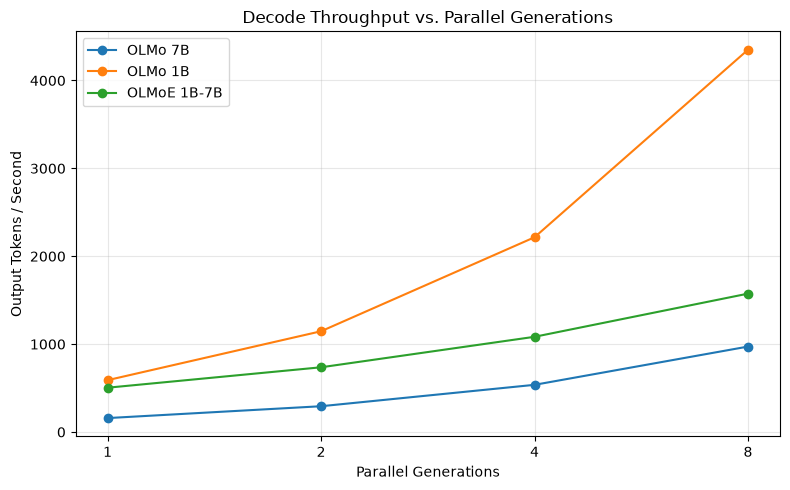

In [26]:
parallel_gens = sorted(moe_decode.keys())

plt.figure(figsize=(8, 5))

plt.plot(
    parallel_gens,
    [large_decode[n] for n in parallel_gens],
    marker="o",
    label="OLMo 7B"
)

plt.plot(
    parallel_gens,
    [small_decode[n] for n in parallel_gens],
    marker="o",
    label="OLMo 1B"
)

plt.plot(
    parallel_gens,
    [moe_decode[n] for n in parallel_gens],
    marker="o",
    label="OLMoE 1B-7B"
)

plt.xlabel("Parallel Generations")
plt.ylabel("Output Tokens / Second")
plt.title("Decode Throughput vs. Parallel Generations")

plt.xscale("log", base=2)
plt.xticks(parallel_gens, parallel_gens)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()